# Example notebook on making an simple XY plot of glacier elevation versus mass balance

Needed data:
- glacier elevation (e.g. from DEM). Gridded or point data are both possible
- glacier mass balance data (or dh/dt data; process is the same for both). Gridded or point data are both possible. 

Steps:
1. load both datasets
2. determine the available range of elevation (min max, e.g. 1600m to 2300m) and construct a discretized array of elevation values (e.g. steps of 100 m ranging from 1600m to 2300m)
3. for each 'elevation bin' (one bin is e.g. 1600-1700, then 1700-1800, etc):
    - identify which mass balance values fall into this bin
    - aggregate these values to have 1 value for that bin. Usually we calculate the average value. 

Outcome:
- the figure shows a curve, and the steepnes of this curve is the 'mass balance gradient' (mwe / m)

M. Izeboud, Brussels, March 2026

In [ ]:

import numpy as np
import xarray as xr 
import rioxarray as rioxr ## needed for loading .grid files with xarray
import geopandas as gpd 
import os
import matplotlib.pyplot as plt
import pandas as pd
import rasterio as rio

## to go from notebooks (current working directory) to data: two levels up to walk to 'ContinuIX', then one level down to 'data' and another level down into each glacier directory
## NB: I work on macbook, so filepaths are 'folder/otherfolder/subfolder' 
##     If you work on windows: filepaths are 'folder\otherfolder\subfolder' (backslashes instead of forward slashes)
## NB: if you have special charachters in your paths (space, parentheses, etc) these can be difficult to work with: 
##     its easier to avoid these and name all your folders and files with '_' instead of spaces.
path2glacierdata = '../../ContinuIX_WP1_data/11_Aletsch/'




## 1. Load elevation data (example for Aletsch)

In [ ]:
## load Aletsch mask: .tif file 
mask_file_17 = os.path.join(path2glacierdata, 'aletsch_mask_2017-2023', 'aletsch_mask_20170901.tif') # use os.path.join to create the path to the file (robust method across mac/windows/linux operating systems)
aletsch_mask_17 = xr.open_dataset(mask_file_17)  # To open geotiffs with xarray, make sure to have package 'rioxarray' installed
# To plot 2D data, we can select the band-layer and drop this dimension to only have a (x,y) matrix
aletsch_mask_17 = aletsch_mask_17.isel(band=0).drop_vars('band').rename({'band_data': 'elevation'})  # select the first (and only) band and drop the 'band' dimension
da_elev = aletsch_mask_17['elevation']

# aletsch_mask_17['band_data'].plot.imshow()

print(da_elev.shape) # (y: 2128 x: 1242) dimensions of the elevation data
print(da_elev.rio.crs)

(2128, 1242)
EPSG:2056


/opt/anaconda3/envs/smb2d/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


In [ ]:
# make list of files:
import glob
aletsch_mb_filelist = os.path.join(path2glacierdata, 'aletsch_smb_extrapolated_2000-2025', '*.grid') # use wildcard to select all .grid files in the directory
mb_filelist = glob.glob(aletsch_mb_filelist) # use glob to get a list of all file paths that match the pattern
mb_filelist.sort() # sort the file list to ensure the files are in the correct order (e.g. from 2000 to 2025)
years_aletsch = np.arange(2000,2025+1)       # construct list of available years
print(f'Found {len(mb_filelist)} available files')

## if files can be assume to have exact same coordinate systems and variables, we can load them all into one xarray dataset using xr.open_mfdataset (multi-file dataset)
ds_mb_aletsch = xr.open_mfdataset(mb_filelist, 
                               engine='rasterio',
                               combine='nested',  # use combine='nested' to combine the files that have the same x,y but should be stack along a new dimension (e.g. time)
                               concat_dim='time', # specify what to call the new dimension along which the files will be concatenated 
                               compat='broadcast_equals', # how to handle differences
                               ).isel(band=0).drop_vars('band') # again drop the band dimension
ds_mb_aletsch = ds_mb_aletsch.rename({'band_data':'mb'}) # rename the data variable to 'mb' for convenience
ds_mb_aletsch.time.values ## initially the time values are just from 0 to 24 
ds_mb_aletsch = ds_mb_aletsch.assign_coords(time=years_aletsch) # replace the time values with the actual years (make sure the order of the years matches the order of the files)
ds_mb_aletsch # (time, y, x) dimensions


## for now, I'm calculating the average mb over the whole timeseries. But you can also do this for each year seperately
da_mb_mean = ds_mb_aletsch.mean(dim='time')['mb'] # average over time dimension, resulting in a (y,x) dataset
da_mb_mean.rio.write_crs('EPSG:21781', inplace=True) # set the coordinate reference system (CRS) for the mb data (inferred in the other notebook)
print(da_mb_mean.shape) 
print(da_mb_mean.rio.crs)


Found 26 available files
(429, 261)
EPSG:21781


/opt/anaconda3/envs/smb2d/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


### 1b preprocess make sure elevation and mass balance are on the same grid.
In this case, we have elevation at a much higher resolution than mass balance, so downsample the elevation to the same grid as mass balance

In [ ]:
def reproject_match_grid( ref_img_da, img_da , resample_method=rio.enums.Resampling.bilinear, nodata_value=np.nan):
    ''' Match xarray grid of different spatial resolutions. Input should be dataArray
    
    ref_img_da.     : xarray dataArray with the reference grid (extent, resolution and projection) to which the other image will be reprojected and resampled to match
    img_da.         : xarray dataArray with the grid that needs to be reprojected 
    resample_method : method to use for resampling (default: bilinear, in a few cases 'nearest' is better)'''

    ## make sure images have a crs available. They don't have to be the same
    if not img_da.rio.crs:
        raise ValueError("img_da does not have a CRS defined. Please define a CRS for this image before using this function.")
    if not ref_img_da.rio.crs:
        raise ValueError("ref_img_da does not have a CRS defined. Please define a CRS for this image before using this function.")
    
    # Make sure images have the same dimension and in the same order
    dims = img_da.dims
    if not all(dim in ref_img_da.dims for dim in dims):
        raise ValueError(f"Both images must have the same dimensions. Reference img has dimensions {ref_img_da.dims}, but img has dimensions {img_da.dims}")
    img_da = img_da.transpose(*ref_img_da.dims) # transpose img_da to have the same dimension order as ref_img_da, this is needed for reproject_match to work correctly
    
    # -- reproject (even if same crs) and match grid (extent, resolution and projection)
    img_repr_match = img_da.rio.reproject_match(ref_img_da, resampling=resample_method, nodata=nodata_value) # need to specify nodata, otherwise fills with (inf) number 1.79769313e+308

    # advised to update coords to make the coordinates the exact same due to tiny differences in the coordinate values due to floating precision
    img_repr_match = img_repr_match.assign_coords({
        "y": ref_img_da.y,
        "x": ref_img_da.x,
    })
    
    return img_repr_match.transpose(*dims) # transpose dimension order back to original


## we reporject the elevation data to match the mass-balance grid 
da_elev = reproject_match_grid(da_mb_mean, da_elev, resample_method=rio.enums.Resampling.bilinear, nodata_value=np.nan) 

print('now output is same CRS and same grid:')
print(da_elev.shape , da_elev.rio.crs) # check the shape and crs of the reprojected elevation data
print(da_mb_mean.shape, da_mb_mean.rio.crs) # check the shape and crs of the mass balance data

now output is same CRS and same grid:
(429, 261) EPSG:21781
(429, 261) EPSG:21781


/opt/anaconda3/envs/smb2d/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


## 2. Discretize the elevation data

In [ ]:
# da_elev.plot.imshow()
min_elev = da_elev.min().values
max_elev = da_elev.max().values
print(f'min elevation: {min_elev:.2f} m, max elevation: {max_elev:.2f} m')

## crreate array of elevation bins (e.g. every 100 m)
h_step = 100
elev_bins = np.arange(np.floor(min_elev/h_step)*h_step,          # use np.floor to get lowest bin value of h_min: 1605.06 will be rounded down to 1600
                      np.ceil(max_elev/h_step)*h_step + h_step,  # use np.ceil to get highest bin value of h_max: 4120.26 will be rounded up to 4200, and add one more step to include the last value in the np.arange() (which is right-exclusive by default)
                      h_step
                      ) # create bins that start and end at multiples of h_step
print(f'elevation bins:\n {elev_bins}')


min elevation: 1625.83 m, max elevation: 4111.44 m
elevation bins:
 [1600. 1700. 1800. 1900. 2000. 2100. 2200. 2300. 2400. 2500. 2600. 2700.
 2800. 2900. 3000. 3100. 3200. 3300. 3400. 3500. 3600. 3700. 3800. 3900.
 4000. 4100. 4200.]


#### spatial visualisation of which pixels belong to the same bin (this step is not necessary , just a for insight on what is happening)

[None, None]

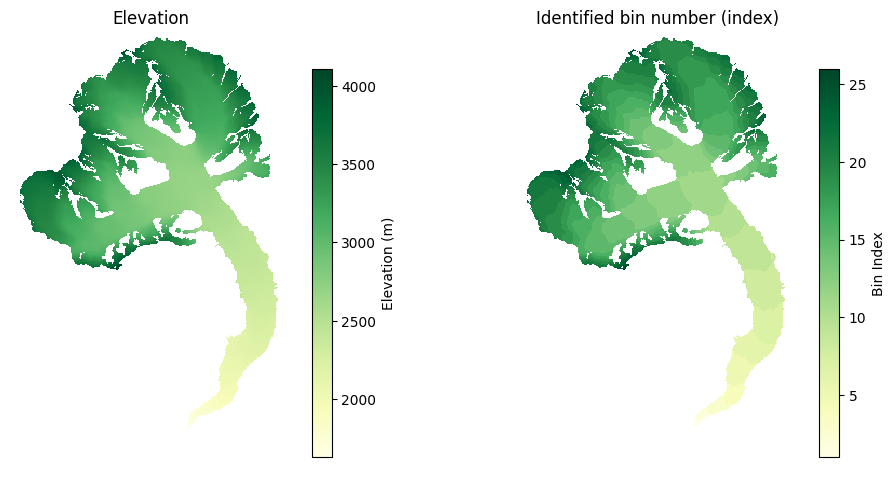

In [ ]:
## return bin-index per pix: 2D elev-bin-idx 
da_elev_bin_idx = xr.apply_ufunc(
    np.digitize,  # Return the indices of the bins to which each value in input array belongs.
    da_elev,   # array to bin
    elev_bins, # bin values
    kwargs={'right': True}  # Ensure right-inclusiveness per bin
)

fig, axs = plt.subplots(1,2, figsize=(12,6))

da_elev.plot.imshow(ax=axs[0],cmap='YlGn' , cbar_kwargs={'label':'Elevation (m)','fraction':0.046}); 
axs[0].set_title('Elevation')

da_elev_bin_idx.where(~np.isnan(da_elev)).plot.imshow(ax=axs[1],cmap='YlGn', cbar_kwargs={'label':'Bin Index','fraction':0.046}); 
axs[1].set_title('Identified bin number (index)')

[ax.set_aspect('equal') for ax in axs]
[ax.set_axis_off() for ax in axs]

## 3. Aggregating data into bins: 
- both 'pandas dataframes' (tables) and 'xarray DataArray' (gridded data) offer usefull tools to aggregate your data
- for xarray this function is 'groupby_bins' and for pandas it is 'cut' (cutting data into bins).

### 3a. binning dataArray:
- you can use 'groupby_bins': this functions effectively assemble (group) all samples/pixels that fall in the same category (e.g a certain elevation range, called bins) and compute a value from these groups.
- NB: the data will be grouped to these bins, and the values represent the LEFT edge of the bin (so bin of 1600-1700 will be represented by the value 1600). 
    It is important to check how the boundary values are handled (are values <1600 (left edge) excluded, or included in the 1600-1700 bin? What about values at the right edge (> h_max) ? )


In [ ]:
## (A) binning a spatial dataset, an xarray data arrray (short: da)

## NB: the data will be grouped to these bins, and the values represent the LEFT edge of the bin (so bin of 1600-1700 will be represented by the value 1600)
## define edges of elevation bins. 
elev_bins_edges = np.concatenate((elev_bins, [elev_bins[-1]+h_step])) # add one more bin edge at the end to include the last bin 

def bin_da_to_elevbins(da, da_elev, bin_edges):
    ''' Bin the values of a dataArray (da) according to the elevation bins defined by da_elev and bin_edges.

    da        : xarray dataArray with the values to be binned (e.g. mass balance)
    da_elev   : xarray dataArray with the elevation values for each pixel (must have the same grid and CRS as da)
    bin_edges : array of bin edges (e.g. [1600, 1700, 1800, ...]) that define the elevation bins
    
    returns : 
    bin_means_data   : array with the mean value of dataArray per elevation bin
    bin_std          : array with the standard deviation of da per elevation bin
    binned_px_counts : array with the number of valid pixels (i.e. excluding NaN) per elevation bin
    '''
    binned_data = da.groupby_bins(                # 2D datavalue to bin
                            group = da_elev,      # 2D bin data to identify groups
                            bins  = bin_edges,    # bin edges -- for edges [1, 2, 3] two bins will be returned 
                            right = True,         # include rightmost edge. If True, then bin_edges [1,2,3,5] indicate (1,2], (2,3], (3,4] ie. right-inclusive
                            include_lowest = True # True # whether the FRIST interval is left-inclusive, so  bins of   [1,2], (2,3], (3,4] 
                            )
    ## the main thing we want to calculate: the mean of all the pixels in the bin
    bin_means_data = binned_data.mean().values    # mean per bin

    ## other potentially useful information can also be retrieved
    binned_px_counts = binned_data.count().values # counts number of valid pixels per bin (i.e. excluding NaN)
    bin_std = binned_data.std().values            # std deviation within bin

    return bin_means_data, bin_std, binned_px_counts

## bin the mass balance data to the elevation bins
smb_bin_means, smb_bin_std, smb_binned_px_counts = bin_da_to_elevbins(da_mb_mean, da_elev, elev_bins_edges)
smb_bin_means


array([-13.289035  , -13.294818  , -13.200333  , -12.196281  ,
       -11.038754  ,  -9.8041115 ,  -8.5598955 ,  -6.8603325 ,
        -5.7830863 ,  -4.634922  ,  -3.6339154 ,  -2.7014632 ,
        -1.5975449 ,  -0.80060583,  -0.09489106,   0.5218531 ,
         1.075555  ,   1.4618857 ,   1.4285047 ,   1.4933196 ,
         1.5736272 ,   1.5637859 ,   1.4243854 ,   1.1493653 ,
         1.111401  ,   1.1171951 ,          nan], dtype=float32)

### Plot output

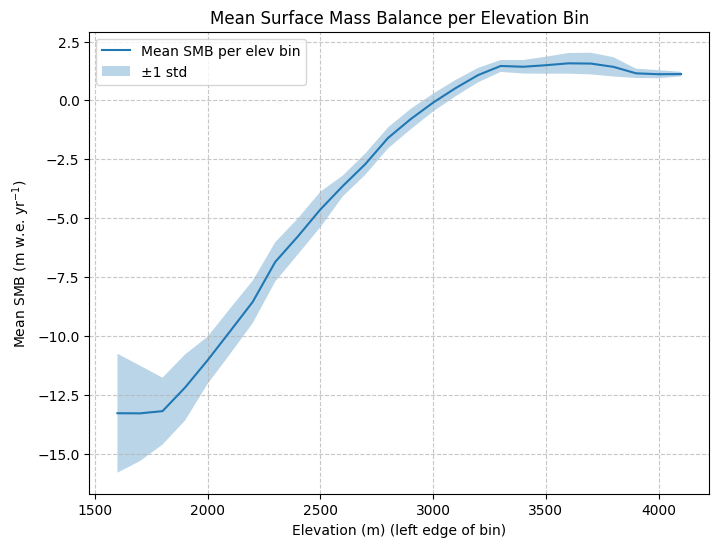

In [ ]:

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(elev_bins, smb_bin_means, label='Mean SMB per elev bin')
ax.fill_between(elev_bins, smb_bin_means - smb_bin_std, smb_bin_means + smb_bin_std, alpha=0.3, label='±1 std')
ax.set_xlabel('Elevation (m) (left edge of bin)')
ax.set_ylabel('Mean SMB (m w.e. yr$^{-1}$)')
ax.set_title('Mean Surface Mass Balance per Elevation Bin')
ax.grid('major', linestyle='--', alpha=0.7)
ax.legend()

### 3b. binning stake data (pandas dataframe) 
- you can use 'cut' and 'groupby_bins'
- for your stake values, you usually do not need a seperate elevation datafile, often the elevation is noted within the stake measurements file, so you can use this directly.
- NB: the elevation range of your stake measurements is probably different than that of the gridded data, so be careful to define/use the same elevation bins


In [ ]:
## aletsch_smb_filt
file_smb_filt = os.path.join(path2glacierdata, 'aletsch_smb_filt_2017-2023.csv')

## use pandas to read the csv file. Gives a dataframe (short: df)
df_smb_stakes = pd.read_csv(file_smb_filt)

## visulise the dataframe: indeed there is a column called 'elev' that we can use
df_smb_stakes



,Name,lon,lat,elev,smb,N_yrs
0,P3,2.641830e+06,1.154798e+06,3334.985714,0.92900,7
1,PN,2.647431e+06,1.140780e+06,1989.333333,-10.70700,3
2,al10,2.649245e+06,1.143879e+06,2242.250000,-7.01550,4
3,al2,2.642935e+06,1.153856e+06,3102.000000,-0.18000,1
4,al4,2.643842e+06,1.152558e+06,2850.250000,-2.40975,4
5,al5,2.645173e+06,1.151394e+06,2724.333333,-3.60000,3
6,al6,2.646304e+06,1.149764e+06,2638.500000,-3.91725,4
7,al7,2.647506e+06,1.148367e+06,2518.500000,-5.39100,2
8,al8,2.648481e+06,1.147104e+06,2418.200000,-5.17680,5
9,al9,2.649253e+06,1.144745e+06,2297.000000,-5.85000,1


In [ ]:
## 1. Use 'cut' to identify in which bin each sample belongs
df_bin_position = pd.cut(df_smb_stakes['elev'],  ## select elevation data
                        bins = elev_bins,        ## use the same elevation_bins as defined previously. 
                        include_lowest=True,     ## include lowest value in the first bin (e.g. 1600 will be included in the 1600-1700 bin). 
                                                    ## bin_edges [1,2,3,5] will yield bins (1,2], (2,3], (3,4] ie. right-inclusive
                        right=True,              ## include right edge in the bin (e.g. 1700 will be included in the 1600-1700 bin, but not in the 1700-1800 bin. 
                                                    ## For bin_edges [1,2,3,5] this yields (1,2], (2,3], (3,4] ie. right-inclusive
                        )
df_bin_position

## can also put it back into the original dataframe to get an overview. These values are of 'categorical' type.
df_smb_stakes['elev_bin_category'] = df_bin_position
df_smb_stakes


,Name,lon,lat,elev,smb,N_yrs,elev_bin_category
0,P3,2.641830e+06,1.154798e+06,3334.985714,0.92900,7,"(3300.0, 3400.0]"
1,PN,2.647431e+06,1.140780e+06,1989.333333,-10.70700,3,"(1900.0, 2000.0]"
2,al10,2.649245e+06,1.143879e+06,2242.250000,-7.01550,4,"(2200.0, 2300.0]"
3,al2,2.642935e+06,1.153856e+06,3102.000000,-0.18000,1,"(3100.0, 3200.0]"
4,al4,2.643842e+06,1.152558e+06,2850.250000,-2.40975,4,"(2800.0, 2900.0]"
5,al5,2.645173e+06,1.151394e+06,2724.333333,-3.60000,3,"(2700.0, 2800.0]"
6,al6,2.646304e+06,1.149764e+06,2638.500000,-3.91725,4,"(2600.0, 2700.0]"
7,al7,2.647506e+06,1.148367e+06,2518.500000,-5.39100,2,"(2500.0, 2600.0]"
8,al8,2.648481e+06,1.147104e+06,2418.200000,-5.17680,5,"(2400.0, 2500.0]"
9,al9,2.649253e+06,1.144745e+06,2297.000000,-5.85000,1,"(2200.0, 2300.0]"


In [ ]:

## 2. aggregate data per bin to get 1 value per bin
# NB: need to specify which columns to use, since calculating a 'mean' over the column 'Name' (text) does not work
df_mb_binned = df_smb_stakes[['elev','smb','elev_bin_category']].groupby('elev_bin_category',observed=False).agg('mean') ## you can also calculate multiple statistics at once, then use agg(['mean','min','max'])
df_mb_binned.reset_index(inplace=True)

## this 
## add a simple column with the hbin edge values
df_mb_binned['hbin_left'] = elev_bins[:-1] # add column with left edge of bin (note that the last bin edge is not included since it is the right edge of the last bin)

df_mb_binned

,elev_bin_category,elev,smb,hbin_left
0,"(1599.999, 1700.0]",NaN,NaN,1600.0
1,"(1700.0, 1800.0]",NaN,NaN,1700.0
2,"(1800.0, 1900.0]",NaN,NaN,1800.0
3,"(1900.0, 2000.0]",1989.333333,-10.70700,1900.0
4,"(2000.0, 2100.0]",NaN,NaN,2000.0
5,"(2100.0, 2200.0]",NaN,NaN,2100.0
6,"(2200.0, 2300.0]",2269.625000,-6.43275,2200.0
7,"(2300.0, 2400.0]",NaN,NaN,2300.0
8,"(2400.0, 2500.0]",2418.200000,-5.17680,2400.0
9,"(2500.0, 2600.0]",2518.500000,-5.39100,2500.0


### plot results
NB: in this example I plot both the 'binned' stake values and the 'original' stake values, using the actual elev per stake.   
In this example stake-dataset there is only one stake per elevation bin, so it actually does **not** make sense to calculate a 'bin-average' for the stake values.  
However, if you have multiple stakes in the same bin, it could still be useful to apply this. Depends on the data, so up to you to decide!

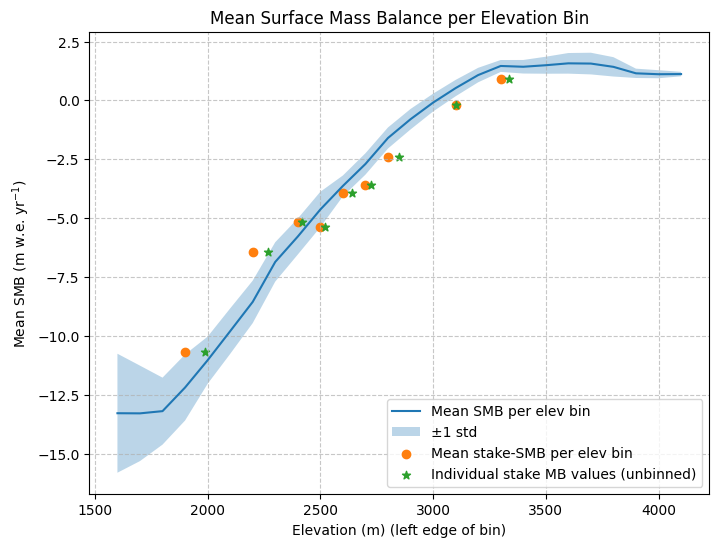

In [ ]:

fig, ax = plt.subplots(figsize=(8,6))

## the binned dataArray
ax.plot(elev_bins, smb_bin_means, label='Mean SMB per elev bin')
ax.fill_between(elev_bins, smb_bin_means - smb_bin_std, smb_bin_means + smb_bin_std, alpha=0.3, label='±1 std')

## the binned stake values
ax.scatter(df_mb_binned['hbin_left'], df_mb_binned['smb'], 
        label='Mean stake-SMB per elev bin', marker='o')
ax.scatter(df_mb_binned['elev'], df_mb_binned['smb'], label='Individual stake MB values (unbinned)', marker='*')

ax.set_xlabel('Elevation (m) (left edge of bin)')
ax.set_ylabel('Mean SMB (m w.e. yr$^{-1}$)')
ax.set_title('Mean Surface Mass Balance per Elevation Bin')
ax.grid('major', linestyle='--', alpha=0.7)
ax.legend()


# Next steps..
- bin and include the dhdt versus elevation in the same plot
- fit a line to this curve to get the mass balance gradient (how steep is the curve: m.w.e. per m elevation)
- ...